cuda:9
[ Load Abeta40 ]
[ total number of true data points : 49 ]


/home/hyunwoocho/26eidgm_final/_trainer.py:730: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()


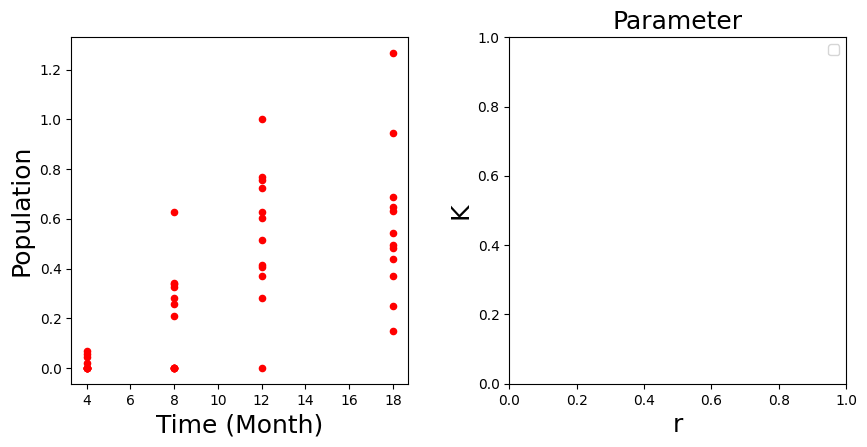

In [1]:
import numpy as np
import torch
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# custom
from _config import get_prms
from _trainer import Trainer
# devisce
device = torch.device("cuda:9" if torch.cuda.is_available() else "cpu")
print(device)

seed = 1234
np.random.seed(seed)
torch.manual_seed(seed)

# problem settings : exponential, logistic, target cell-limited 
name = 'log' # 'exp', 'log', 'virus'
dist_i = 1
dist_list = ['uni', 'bi', 'tri']
dist_type = dist_list[dist_i-1] # 'uni', 'bi', 'tri'
get_plot = True

# hyperparameter settings (prms[0]:DE, prms[1]:hyperPINN, prms[2]:WGAN)
prms = get_prms(name, dist_type=dist_type) # DE / hyperPINN / WGAN settings
prms[1]['deeponet'] = False
if get_plot:
    prms[2]['num_noised'] = 3//dist_i # Insert the number of real paramaters from the each nodes with noise 
    prms[2]['num_gen_plot'] = (1000-1)*5
else:
    prms[2]['num_noised'] = 1000//dist_i # Insert the number of real paramaters from the each nodes with noise 
    prms[2]['num_gen_plot'] = (1000-1)*5
#prms[2]['num_gen_ratio'] = 1 # Insert the ratio : fake data/real data 
prms[2]['num_cut'] = 0 # Insert the number of censored time for each mode which is randomly determined via numpy seed.
#prms

# get dataset : if you want real data 
real_data = 'Abeta40' # None, 'Abeta40', 'Abeta42'
trainer = Trainer(name, prms, device=device)
modes_noisy, X_data, X_data_onehot = trainer.get_data_gan(real_data=real_data)

> model output : gp / deeponet / hyperpinn 

In [2]:
# prepare models
# load pre-trained hyperPINNs
trainer.load_pinn()

# load WGANs
load_params = True # if you want to train WGAN from the begining, then this should be False.
trainer.load_gan(load_params=load_params)

# show WGAN result
#gens = trainer.plot_results_gan(modes_noisy, X_data, plot_traj=False, return_gen=True, get_scores=True)
#trainer.plot_results_real_data(real_data, X_data)

#print(len(modes_noisy), len(gens))

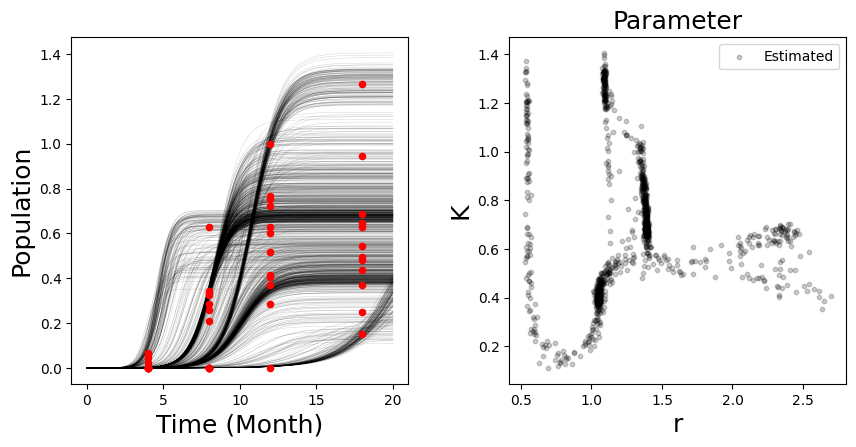

In [3]:
gens = trainer.plot_results_gan(modes_noisy, X_data, plot_traj=True, return_gen=True, get_scores=False)

In [4]:
#trues = pd.DataFrame(np.concatenate([modes_noisy.numpy(), np.reshape(np.array([['true']*len(modes_noisy)]),(-1,1))],-1), columns=['r','K',' ']).astype({'r':float, 'K':float})
fakes = pd.DataFrame(np.concatenate([gens.numpy(), np.reshape(np.array([['estimated']*len(gens)]),(-1,1))],-1), columns=['r','K',' ']).astype({'r':float, 'K':float})
df = pd.concat([fakes])

cc = ['magenta','blue','green']
tc = cc[dist_i-1]
fs = 27
sns.set(font_scale=3)
sns.set_style("ticks", {'axes.grid' : False})

xmin, xmax = -0.5, 5.5
ymin, ymax = 0.3, 1.7
rticks = [1.0,2.5,4.0]
Kticks = [0.6,1.0,1.4]

/home/hyunwoocho/anaconda3/envs/test/lib/python3.13/site-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


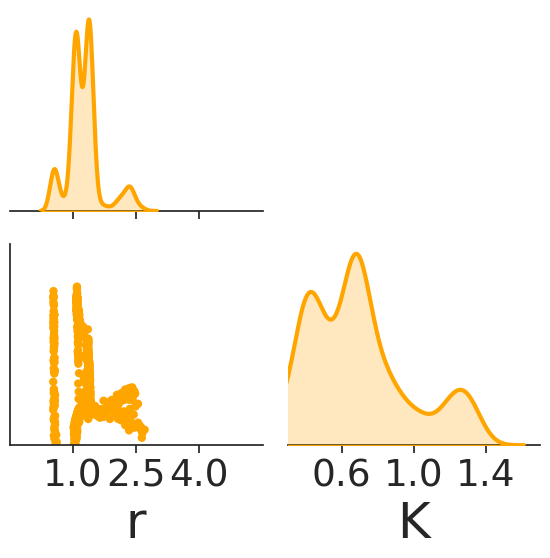

In [5]:
g = sns.pairplot(df, hue =' ', size=3, corner=True, plot_kws=dict(edgecolor="none"), palette={'true':tc, 'estimated':'orange'})
g.map_diag(sns.kdeplot, lw=3) 
for i, ax in enumerate(g.axes.flatten()):
    if i in [0, 2]:
        ax.set_xlabel('r')
        ax.set_ylabel('')
        ax.set_xlim(xmin, xmax)
        ax.set_xticks(rticks)
    if i in [2]:
        ax.set_ylim(ymin, ymax)
        ax.set_yticks([])
        ax.tick_params(axis='both', which='major', labelsize=fs)
    if i in [3]:
        ax.set_xlabel('K')
        ax.set_xlim(ymin, ymax)
        ax.set_xticks(Kticks)
        ax.tick_params(axis='both', which='major', labelsize=fs)      
g.legend.remove()
g.tight_layout()
g.fig.savefig('./fig1_log',dpi=300)